### 매뉴얼

본 프로젝트는 다양한 모델로 다양한 각도에서 분석을 시도한 프로젝트다. 따라서 데이터 수집 및 전처리는 대범주적으로는 3개의 방식(단순 선형 회귀, 다중 선형 회귀, 다항 선형 회귀) 모두 동일한 코드를 사용한다.

In [1]:
import os
import platform
import pandas as pd
import numpy as np
from IPython.display import display # 피쳐가 많은 해당 데이터를 좀 더 보기 쉽도록 하기 위해 불러온다.
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정(모든 OS에서 작동되도록)
if platform.system() == 'Darwin':       # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':    # Windows
    plt.rc('font', family='Malgun Gothic')
else:                                   # Linux / Docker / Cloud
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


# 데이터 로드: ai_companion_dependency_dataset.csv
data= pd.read_csv('data/ai_companion_dependency_dataset.csv')


# 데이터 상위 5열 확인으로 컬럼(피쳐) 파악
print(data.head())

print(data.describe())

  user_id  age      gender   occupation_status education_level  income_level  \
0   U0001   21        Male  Employed Full-Time     High School  Lower-Middle   
1   U0002   34        Male             Student        Graduate  Upper-Middle   
2   U0003   43        Male  Employed Full-Time        Graduate           Low   
3   U0004   29  Non-binary  Employed Full-Time        Graduate           Low   
4   U0005   25      Female             Student        Graduate  Upper-Middle   

  relationship_status living_situation country_region ai_chatbot_platform  \
0   In a Relationship     With Partner  South America             ChatGPT   
1              Single            Alone  North America        Character.AI   
2              Single            Alone         Europe        Character.AI   
3              Single      With Family           Asia             ChatGPT   
4   In a Relationship   With Roommates  South America             ChatGPT   

   ... sleep_hours  sleep_quality_score  exercise_hours_

In [2]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
from IPython.display import display

# ===========================================================================================================
# 1. 데이터 필터링-행 :: (청소년, 넓게는 청년층과 AI에 대한 심리적 문제가 대상이므로, 특정 연령대와 특정 이용목적만을 남긴다.)
# ===========================================================================================================

"""
age: 15세 ~ 24세 (청소년층 / 청년층)
primary_use_cases : Companionship, Entertainment, Therapy-Substitute
"""
target_col = ['Companionship', 'Entertainment', 'Therapy-Substitute']

df_filtered = data[
    (data['age'] >= 15) & (data['age'] <= 24) &
    (data['primary_use_case'].isin(target_col))
].copy()


# ===========================================================================================================
# 2. 데이터 필터링-열 :: 수치형 피처 + 보류했던 범주형 3개 피처만 선택
# ===========================================================================================================

"""
[제외 피쳐 목록]
user_id, gender, country_region, ai_chatbot_platform, prefers_ai_over_humans,
academic_or_work_performance_change, dependency_risk_label,
education_level, income_level, primary_use_case, therapy_attendance

[보류에서 -> 분석 대상으로 추가된 피쳐 3종]
- occupation_status (직업 상태)
- relationship_status (연애/대인 관계 상태)
- living_situation (주거 형태)
"""

# 포함할 분석 대상 피쳐 선택 (수치형 15개 + 보류 피처 3개 + 타깃 1개 = 총 19개)
selected_features = [
    # 기본 인구통계 및 [보류 해제 피처 3개]
    'age',
    'occupation_status',        # [추가] 직업 상태
    'relationship_status',      # [추가] 연애/결혼 상태
    'living_situation',         # [추가] 주거 형태
    
    # 일상 및 디지털 활동 시간 (수치형)
    'daily_ai_chat_hours',
    'human_social_interaction_hours',
    'social_media_hours_daily',
    'screen_time_total_hours',
    
    # 사회적 관계 (수치형)
    'number_of_close_friends',
    'real_relationship_satisfaction',
    
    # 생활 습관 및 수면 (수치형)
    'sleep_hours',
    'sleep_quality_score',
    'exercise_hours_weekly',
    
    # 심리적 척도 (수치형)
    'loneliness_score',
    'anxiety_score',
    'depression_score',
    'stress_score',
    'self_esteem_score',
    
    # 종속 변수 (Target)
    'emotional_attachment_score'
]

# 1차 필터링 데이터프레임 생성
df = df_filtered[selected_features].reset_index(drop=True)

print(f"원본 데이터 크기: {data.shape}")
print(f"필터링 데이터 크기: {df.shape}")

# 필터링한 데이터의 결측치 확인
print(df.isnull().sum())



# ===========================================================================================================
# 3. 오직 [보류 피처 3개]만 원-핫 인코딩 수행 (OneHotEncoder)
# ===========================================================================================================

# 1) 원-핫 인코딩할 3개 피처 지정
categorical_features = ['occupation_status', 'relationship_status', 'living_situation']

# 2) 순수 수치형 피처 목록
numeric_features = [
    'age', 'daily_ai_chat_hours', 'human_social_interaction_hours', 
    'social_media_hours_daily', 'screen_time_total_hours', 'number_of_close_friends', 
    'real_relationship_satisfaction', 'sleep_hours', 'sleep_quality_score', 
    'exercise_hours_weekly', 'loneliness_score', 'anxiety_score', 
    'depression_score', 'stress_score', 'self_esteem_score'
]

target_feature = 'emotional_attachment_score'

# 3) OneHotEncoder로 3개 피처만 변환 (다중공선성 방지 drop='first')
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(df[categorical_features])
encoded_columns = ohe.get_feature_names_out(categorical_features)

df_encoded_cats = pd.DataFrame(encoded_array, columns=encoded_columns)

# 4) 수치형 피처 + 인코딩된 3개 범주형 피처 + 타깃 결합
df_final = pd.concat([df[numeric_features], df_encoded_cats, df[[target_feature]]], axis=1)

# 5) 독립변수 X와 종속변수 y 분리
X = df_final.drop(columns=[target_feature])
y = df_final[target_feature]

# ===========================================================================================================
# 4. 최종 데이터 확인
# ===========================================================================================================
print("\n" + "="*70)
print(f"최종 전처리 완료 데이터 크기: {df_final.shape}")
print(f"독립변수(X) 피처 개수: {X.shape[1]}개 | 종속변수(y) 크기: {y.shape[0]}개")
print("="*70)

print("\n--- [추가된 3개 피처의 더미 컬럼 목록] ---")
print(encoded_columns.tolist())

print("\n--- [최종 데이터 상위 5개 행 (X)] ---")
display(X.head())

원본 데이터 크기: (1000, 30)
필터링 데이터 크기: (196, 19)
age                               0
occupation_status                 0
relationship_status               0
living_situation                  0
daily_ai_chat_hours               0
human_social_interaction_hours    0
social_media_hours_daily          0
screen_time_total_hours           0
number_of_close_friends           0
real_relationship_satisfaction    0
sleep_hours                       0
sleep_quality_score               0
exercise_hours_weekly             0
loneliness_score                  0
anxiety_score                     0
depression_score                  0
stress_score                      0
self_esteem_score                 0
emotional_attachment_score        0
dtype: int64

최종 전처리 완료 데이터 크기: (196, 26)
독립변수(X) 피처 개수: 25개 | 종속변수(y) 크기: 196개

--- [추가된 3개 피처의 더미 컬럼 목록] ---
['occupation_status_Employed Part-Time', 'occupation_status_Freelancer', 'occupation_status_Student', 'occupation_status_Unemployed', 'relationship_status_In a R

,age,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,real_relationship_satisfaction,sleep_hours,sleep_quality_score,exercise_hours_weekly,...,occupation_status_Employed Part-Time,occupation_status_Freelancer,occupation_status_Student,occupation_status_Unemployed,relationship_status_In a Relationship,relationship_status_Married,relationship_status_Single,living_situation_With Family,living_situation_With Partner,living_situation_With Roommates
0,22,0.94,5.49,2.46,5.10,4,5.5,5.8,7.1,2.6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,17,0.00,4.96,1.86,5.42,4,8.8,9.3,7.7,6.1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,16,1.47,5.18,2.70,6.23,6,3.8,8.1,5.2,5.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,24,0.00,4.91,0.65,1.79,7,10.0,7.1,7.9,4.9,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,17,0.00,4.43,0.52,3.03,3,8.4,9.2,9.5,4.1,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


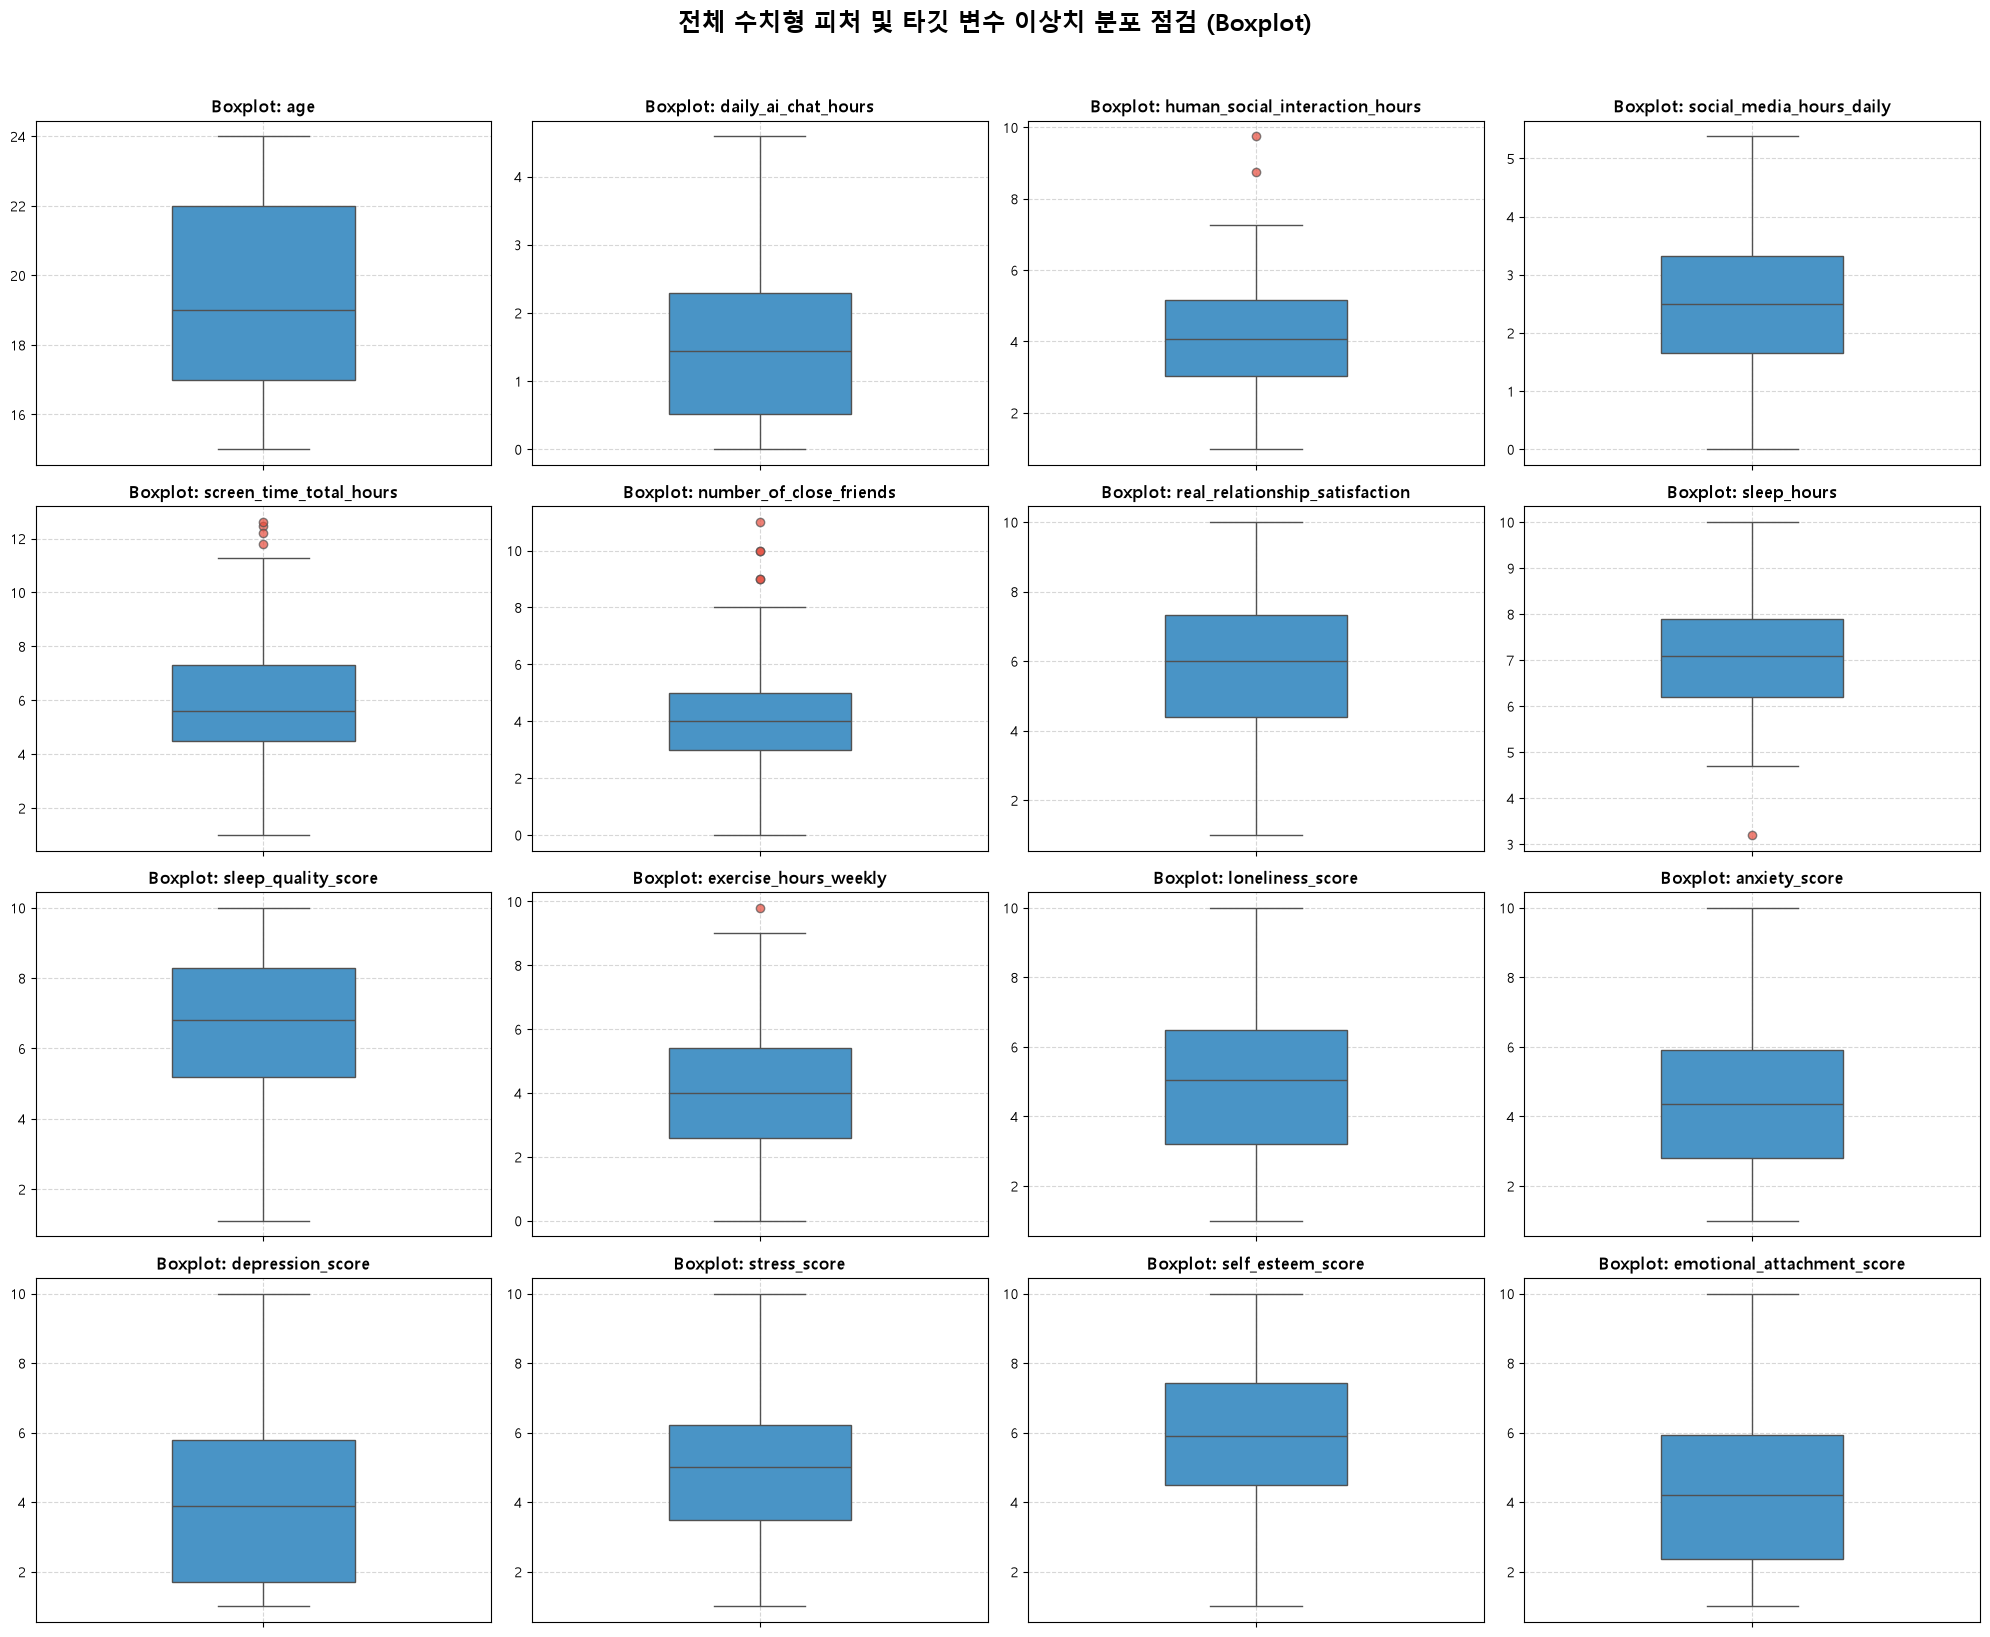


=================== [수치형 피처 IQR 기준 이상치 요약 통계표] ===================


,피처명,Q1 (25%),Q3 (75%),IQR,하한선 (Lower),상한선 (Upper),이상치 개수,이상치 비율(%)
0,age,17.00,22.00,5.00,9.50,29.50,0,0.00%
1,daily_ai_chat_hours,0.52,2.30,1.78,-2.14,4.96,0,0.00%
2,human_social_interaction_hours,3.04,5.16,2.12,-0.13,8.33,2,1.02%
3,social_media_hours_daily,1.65,3.32,1.67,-0.86,5.83,0,0.00%
4,screen_time_total_hours,4.50,7.31,2.81,0.29,11.52,4,2.04%
5,number_of_close_friends,3.00,5.00,2.00,0.00,8.00,5,2.55%
6,real_relationship_satisfaction,4.40,7.32,2.92,0.01,11.71,0,0.00%
7,sleep_hours,6.20,7.90,1.70,3.65,10.45,1,0.51%
8,sleep_quality_score,5.20,8.30,3.10,0.55,12.95,0,0.00%
9,exercise_hours_weekly,2.60,5.43,2.83,-1.64,9.66,1,0.51%


In [3]:
# ===========================================================================================================
# [데이터 탐색/전처리] 수치형 피처 이상치(Outlier) 점검 (Boxplot & IQR 분석)
# ===========================================================================================================

# 1. 점검할 전체 수치형 피처 목록 (수치형 15개 + 타깃 1개 = 총 16개)
check_numeric_cols = numeric_features + [target_feature]

# 2. 4행 4열 서브플롯(Subplots)으로 전체 수치형 피처 Boxplot 시각화
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(check_numeric_cols):
    sns.boxplot(
        data=df, 
        y=col, 
        ax=axes[idx], 
        color='#3498db', 
        width=0.4,
        flierprops={'marker': 'o', 'markersize': 6, 'markerfacecolor': '#e74c3c', 'alpha': 0.7}
    )
    axes[idx].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('')
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('전체 수치형 피처 및 타깃 변수 이상치 분포 점검 (Boxplot)', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ===========================================================================================================
# 3. IQR (Interquartile Range) 기준 이상치 개수 및 비율 통계표 계산
# ===========================================================================================================
outlier_summary = []

for col in check_numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # 이상치 행 필터링
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df)) * 100
    
    outlier_summary.append({
        '피처명': col,
        'Q1 (25%)': round(Q1, 2),
        'Q3 (75%)': round(Q3, 2),
        'IQR': round(IQR, 2),
        '하한선 (Lower)': round(lower_bound, 2),
        '상한선 (Upper)': round(upper_bound, 2),
        '이상치 개수': outlier_count,
        '이상치 비율(%)': f"{outlier_pct:.2f}%"
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\n=================== [수치형 피처 IQR 기준 이상치 요약 통계표] ===================")
display(outlier_df)


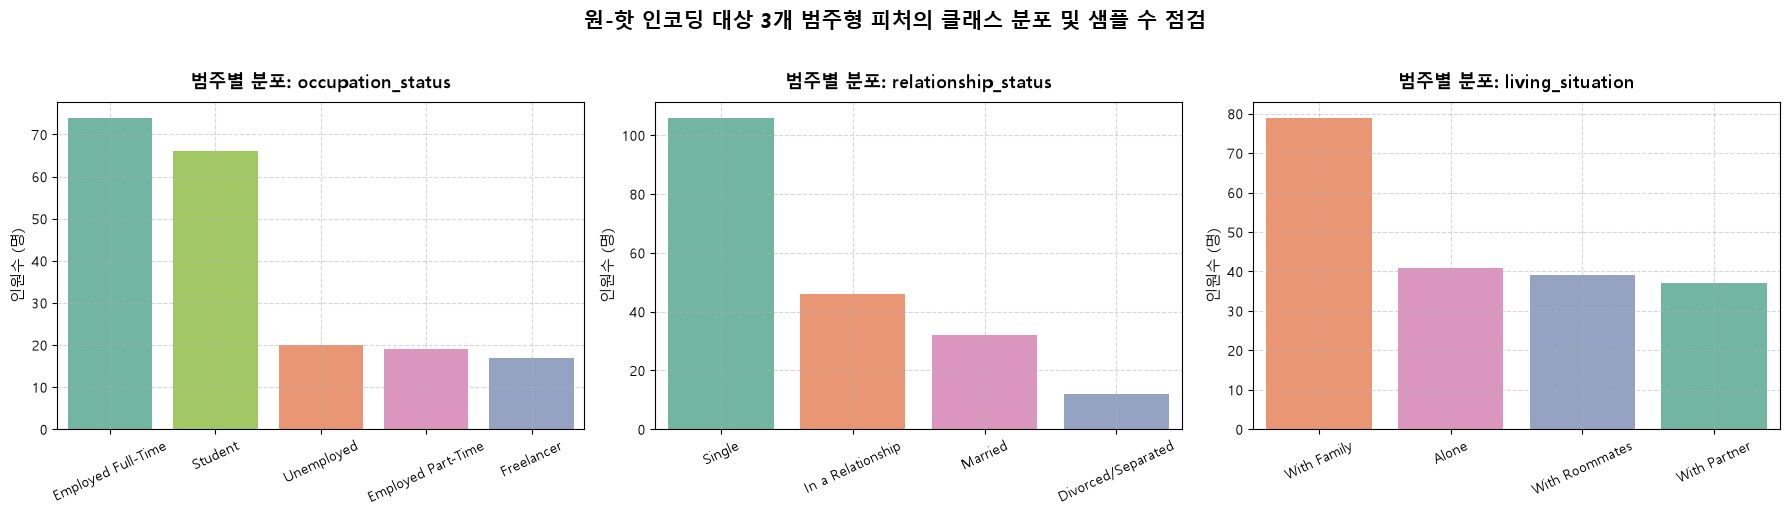

=================== [범주형 피처별 인원수 및 비율 요약표] ===================


,피처명,세부 카테고리,인원수(명),비율(%)
0,occupation_status,Employed Full-Time,74,37.8%
1,occupation_status,Student,66,33.7%
2,occupation_status,Unemployed,20,10.2%
3,occupation_status,Employed Part-Time,19,9.7%
4,occupation_status,Freelancer,17,8.7%
5,relationship_status,Single,106,54.1%
6,relationship_status,In a Relationship,46,23.5%
7,relationship_status,Married,32,16.3%
8,relationship_status,Divorced/Separated,12,6.1%
9,living_situation,With Family,79,40.3%



--- [해석 가이드] ---
1. 특정 카테고리의 비율이 지나치게 희소하지 않은지 확인합니다.
2. OneHotEncoder(drop='first') 적용 시 각 피처의 첫 번째 카테고리가 기준(Base) 그룹이 됩니다.


In [4]:
# ===========================================================================================================
# [범주형 피처 전처리 점검] 원-핫 인코딩 대상 피처(직업, 연애, 주거) 클래스 분포 및 희소 범주 점검
# ===========================================================================================================

# 1. 1행 3열 서브플롯(Subplots)으로 3개 범주형 변수의 클래스별 인원수 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col in enumerate(categorical_features):
    order_idx = df[col].value_counts().index
    sns.countplot(
        data=df, 
        x=col, 
        ax=axes[idx], 
        order=order_idx,
        hue=col,
        palette='Set2',
        legend=False
    )
    axes[idx].set_title(f'범주별 분포: {col}', fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('인원수 (명)', fontsize=11)
    axes[idx].tick_params(axis='x', rotation=25)
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('원-핫 인코딩 대상 3개 범주형 피처의 클래스 분포 및 샘플 수 점검', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 2. 각 범주형 변수별 빈도수(명) 및 비율(%) 요약 테이블 출력
print("=================== [범주형 피처별 인원수 및 비율 요약표] ===================")
summary_cat_list = []

for col in categorical_features:
    cnt = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    for cat_name in cnt.index:
        summary_cat_list.append({
            '피처명': col,
            '세부 카테고리': cat_name,
            '인원수(명)': cnt[cat_name],
            '비율(%)': f"{pct[cat_name]:.1f}%"
        })

cat_distribution_df = pd.DataFrame(summary_cat_list)
display(cat_distribution_df)

print("\n--- [해석 가이드] ---")
print("1. 특정 카테고리의 비율이 지나치게 희소하지 않은지 확인합니다.")
print("2. OneHotEncoder(drop='first') 적용 시 각 피처의 첫 번째 카테고리가 기준(Base) 그룹이 됩니다.")


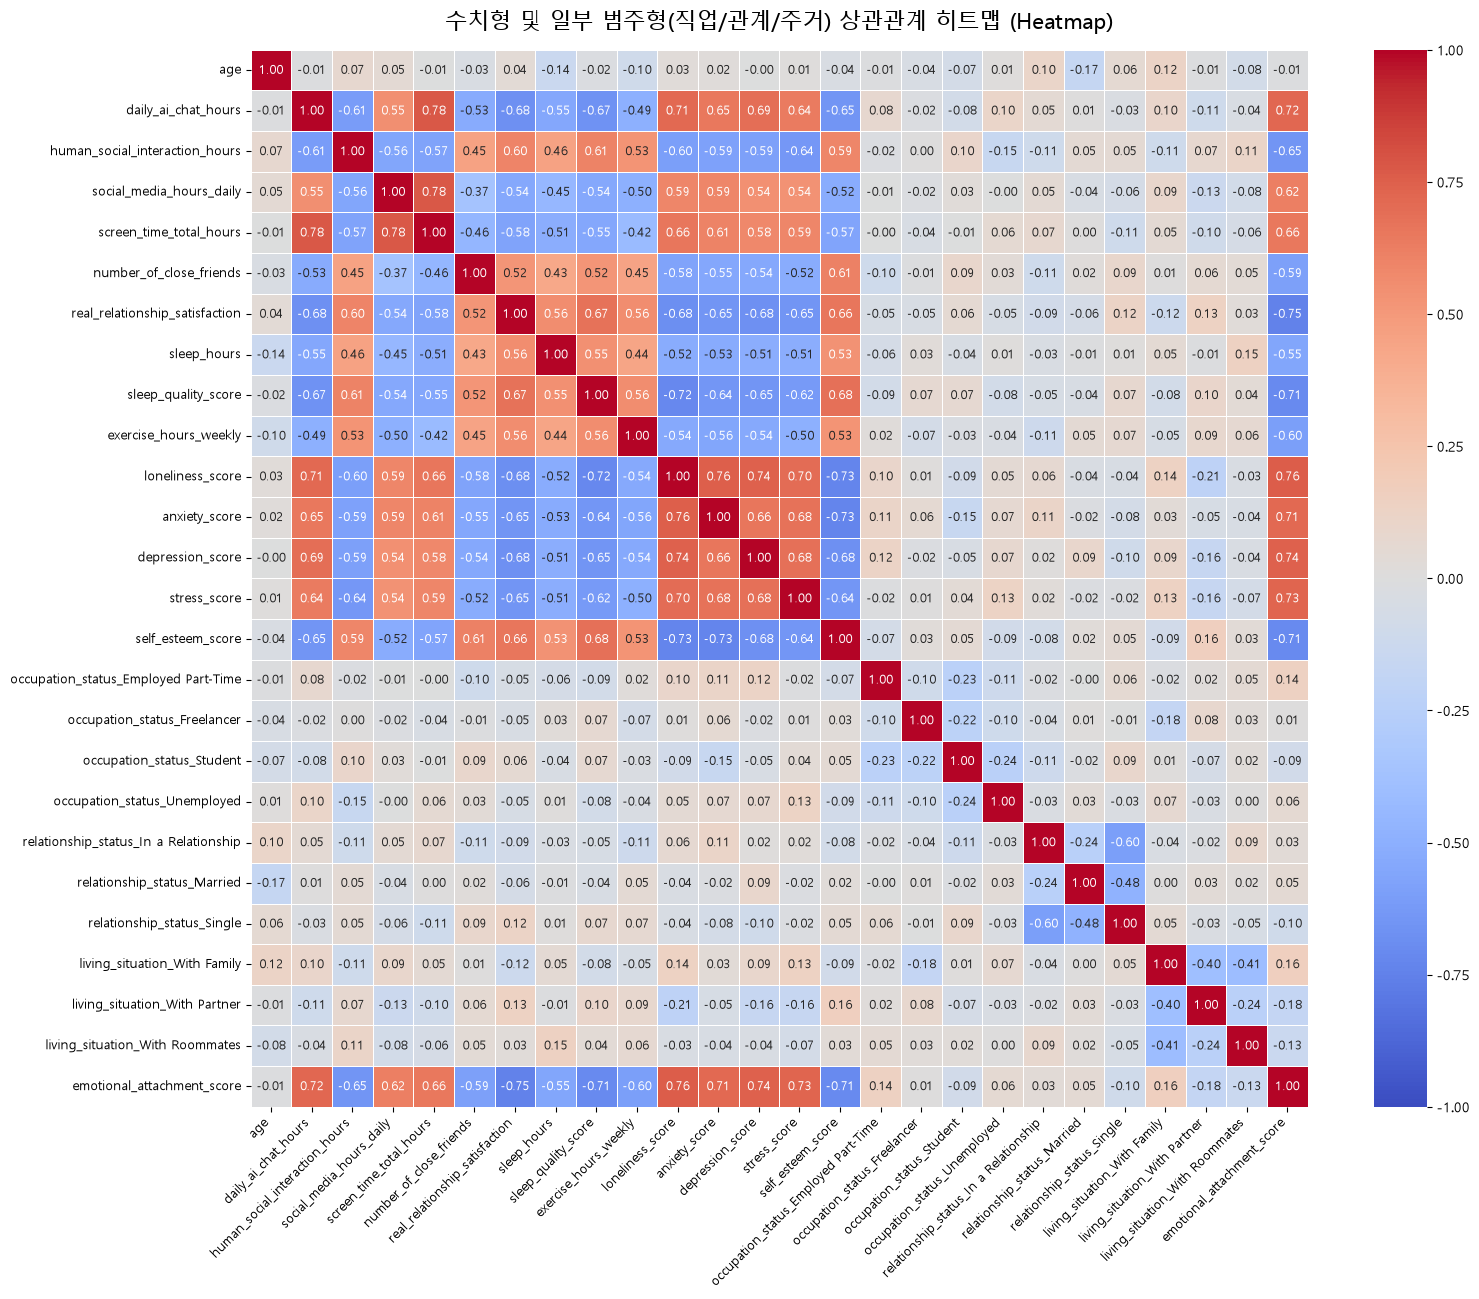

In [5]:
# ===========================================================================================================
# EDA: 상관관계 히트맵 (수치형 피처 + 보류 해제 범주형 3종 피처)
# ===========================================================================================================

# 수치형 피처 + 보류 해제 범주형 3종 더미 변수가 포함된 df_final 기준으로 상관계수 행렬 계산
corr_matrix = df_final.corr()

# 히트맵 시각화
plt.figure(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    annot_kws={'size': 9}
)
plt.title('수치형 및 일부 범주형(직업/관계/주거) 상관관계 히트맵 (Heatmap)', fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

--- [정서적 애착도(Target)와 상관관계 상위 6개 피처] ---
  1위: loneliness_score                    (상관계수 r = +0.760)
  2위: real_relationship_satisfaction      (상관계수 r = -0.747)
  3위: depression_score                    (상관계수 r = +0.743)
  4위: stress_score                        (상관계수 r = +0.728)
  5위: daily_ai_chat_hours                 (상관계수 r = +0.719)
  6위: anxiety_score                       (상관계수 r = +0.712)


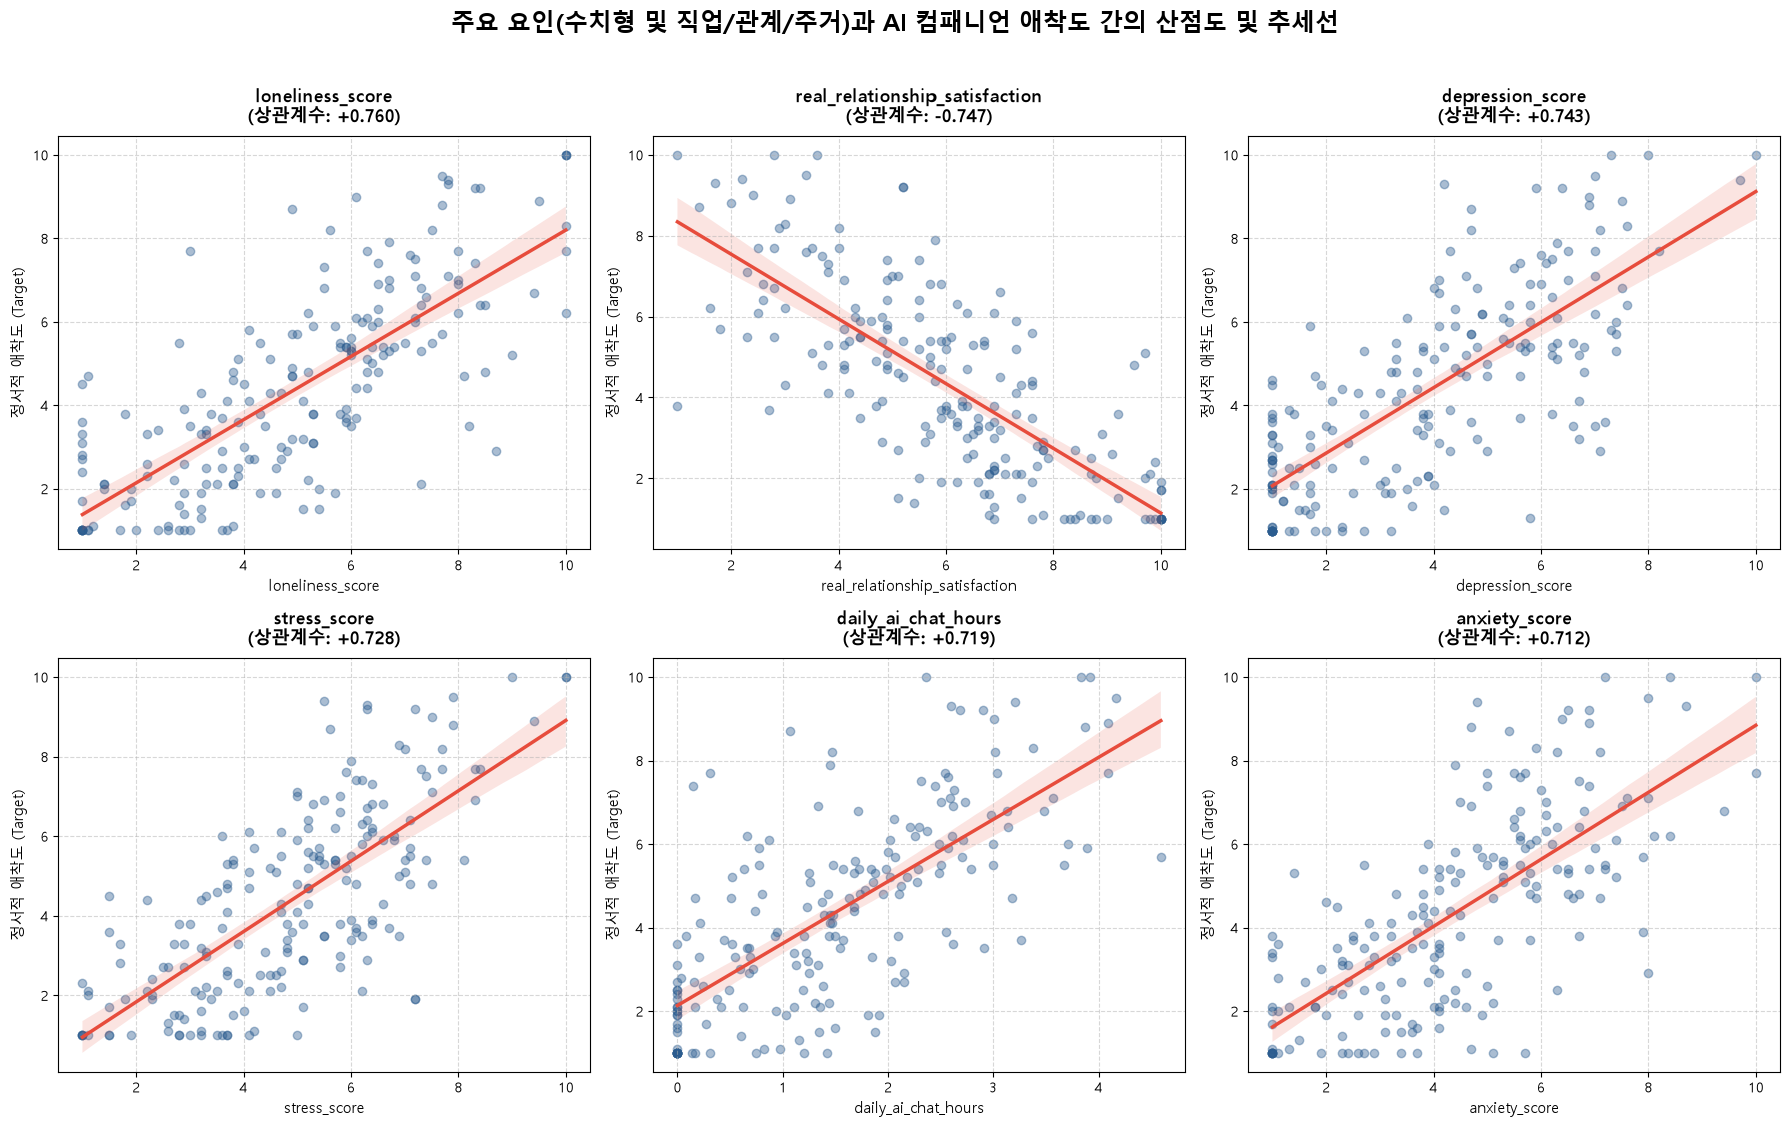

In [6]:
# ===========================================================================================================
# EDA: 종속 변수(Target) vs 주요 요인 간의 산점도 및 선형 추세선 시각화
# ===========================================================================================================

# 1. 타깃(emotional_attachment_score)과 상관관계 절댓값이 가장 큰 상위 6개 피처 자동 추출
corr_series = df_final.corr()['emotional_attachment_score'].drop('emotional_attachment_score')
top_6_features = corr_series.abs().sort_values(ascending=False).head(6).index.tolist()

print("--- [정서적 애착도(Target)와 상관관계 상위 6개 피처] ---")
for rank, feat in enumerate(top_6_features, 1):
    print(f"  {rank}위: {feat:<35} (상관계수 r = {corr_series[feat]:+.3f})")

# 2. 2행 3열 서브플롯(Subplots) 생성
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for idx, feature in enumerate(top_6_features):
    corr_val = corr_series[feature]
    
    # seaborn의 regplot으로 산점도 + 단순 선형 회귀 추세선 함께 시각화
    sns.regplot(
        data=df_final,
        x=feature,
        y='emotional_attachment_score',
        ax=axes[idx],
        scatter_kws={'alpha': 0.4, 'color': '#2b5c8f'}, # 점 투명도 및 색상
        line_kws={'color': '#e74c3c', 'linewidth': 2.5}  # 회귀선 색상 및 두께
    )
    
    # 그래프 서식 설정
    axes[idx].set_title(f'{feature}\n(상관계수: {corr_val:+.3f})', fontsize=13, fontweight='bold', pad=10)
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('정서적 애착도 (Target)', fontsize=11)
    axes[idx].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('주요 요인(수치형 및 직업/관계/주거)과 AI 컴패니언 애착도 간의 산점도 및 추세선', fontsize=17, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# ===========================================================================================================
# 5. 데이터 분할 (Train / Test Split)
# ===========================================================================================================
# 독립변수 X: 상관계수가 가장 높은 'loneliness_score' (외로움 점수, r = +0.760)
# 종속변수 y: 'emotional_attachment_score' (AI 컴패니언 정서적 애착도)
X = df[['loneliness_score']]
y = df['emotional_attachment_score']

# 훈련 데이터 80%, 테스트 데이터 20% 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"전체 데이터 수: {len(df)}")
print(f"훈련 데이터 크기 (X_train): {X_train.shape}")
print(f"테스트 데이터 크기 (X_test) : {X_test.shape}")

# ===========================================================================================================
# 6. 모델 선택 및 7. 학습
# ===========================================================================================================
model = LinearRegression()
model.fit(X_train, y_train)

# 회귀계수(기울기 W) 및 절편(b) 확인
coef = model.coef_[0]
intercept = model.intercept_

print("\n--- [학습된 단순선형 회귀 모델 방정식] ---")
print(f"Y (정서적 애착도) = {coef:.4f} * X (외로움 점수) + ({intercept:.4f})")


전체 데이터 수: 196
훈련 데이터 크기 (X_train): (156, 1)
테스트 데이터 크기 (X_test) : (40, 1)

--- [학습된 단순선형 회귀 모델 방정식] ---
Y (정서적 애착도) = 0.7383 * X (외로움 점수) + (0.6548)


In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===========================================================================================================
# 8. 모델 평가 (Evaluation)
# ===========================================================================================================
# 훈련 데이터 및 테스트 데이터 예측 수행
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# 1. MSE (Mean Squared Error, 평균 제곱 오차)
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

# 2. RMSE (Root Mean Squared Error, 평균 제곱근 오차)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

# 3. MAE (Mean Absolute Error, 평균 절대 오차)
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

# 4. R² Score (결정계수)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("=================== [단순선형 회귀 모델 평가 결과] ===================")
print(f"[Train 훈련 세트 성능]")
print(f"  - MSE  (평균 제곱 오차)   : {train_mse:.4f}")
print(f"  - RMSE (평균 제곱근 오차) : {train_rmse:.4f}")
print(f"  - MAE  (평균 절대 오차)   : {train_mae:.4f}")
print(f"  - R²   (결정계수)        : {train_r2:.4f}")

print(f"\n[Test 테스트 세트 성능]")
print(f"  - MSE  (평균 제곱 오차)   : {test_mse:.4f}")
print(f"  - RMSE (평균 제곱근 오차) : {test_rmse:.4f}")
print(f"  - MAE  (평균 절대 오차)   : {test_mae:.4f}")
print(f"  - R²   (결정계수)        : {test_r2:.4f}")


=================== [단순선형 회귀 모델 평가 결과] ===================
[Train 훈련 세트 성능]
  - MSE  (평균 제곱 오차)   : 2.3273
  - RMSE (평균 제곱근 오차) : 1.5255
  - MAE  (평균 절대 오차)   : 1.1748
  - R²   (결정계수)        : 0.5536

[Test 테스트 세트 성능]
  - MSE  (평균 제곱 오차)   : 2.3390
  - RMSE (평균 제곱근 오차) : 1.5294
  - MAE  (평균 절대 오차)   : 1.3018
  - R²   (결정계수)        : 0.6448


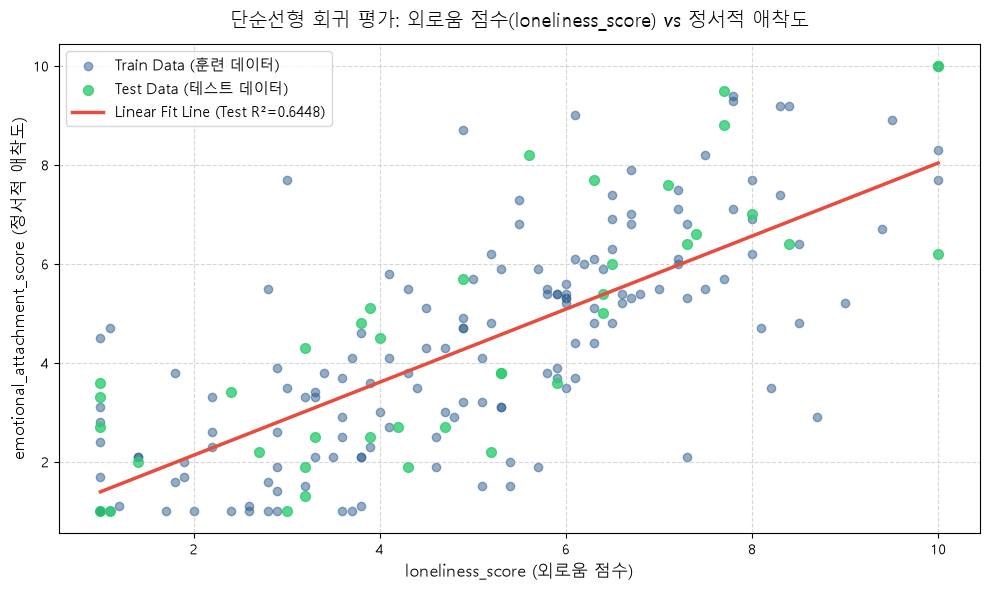

In [9]:
# ===========================================================================================================
# 단순선형 회귀 시각화 (실제 데이터 산점도 + 추정 회귀선)
# ===========================================================================================================
plt.figure(figsize=(10, 6))

# 훈련 데이터 산점도
plt.scatter(X_train, y_train, color='#2b5c8f', alpha=0.5, label='Train Data (훈련 데이터)')
# 테스트 데이터 산점도
plt.scatter(X_test, y_test, color='#2ecc71', alpha=0.8, s=50, label='Test Data (테스트 데이터)')

# 회귀선 그리기
X_line = pd.DataFrame({'loneliness_score': np.linspace(X['loneliness_score'].min(), X['loneliness_score'].max(), 100)})
y_line = model.predict(X_line)
plt.plot(X_line['loneliness_score'], y_line, color='#e74c3c', linewidth=2.5, label=f'Linear Fit Line (Test R²={test_r2:.4f})')

plt.title('단순선형 회귀 평가: 외로움 점수(loneliness_score) vs 정서적 애착도', fontsize=14, pad=12)
plt.xlabel('loneliness_score (외로움 점수)', fontsize=12)
plt.ylabel('emotional_attachment_score (정서적 애착도)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


=================== [단순선형 회귀: 핵심 2대 요인 1:1 성능 비교표] ===================


,모델 구분,독립변수 (X),상관계수 (r),학습된 회귀 방정식,Train R²,Test R²,Test RMSE,Test MAE
0,[양의 상관 1위] 외로움 점수 모델,loneliness_score,+0.760,Y = 0.7383 * X + (0.6548),0.5536,0.6448,1.5294,1.3018
1,[음의 상관 1위] 현실관계 만족도 모델,real_relationship_satisfaction,-0.747,Y = -0.8060 * X + (9.1170),0.5572,0.5533,1.7151,1.3801


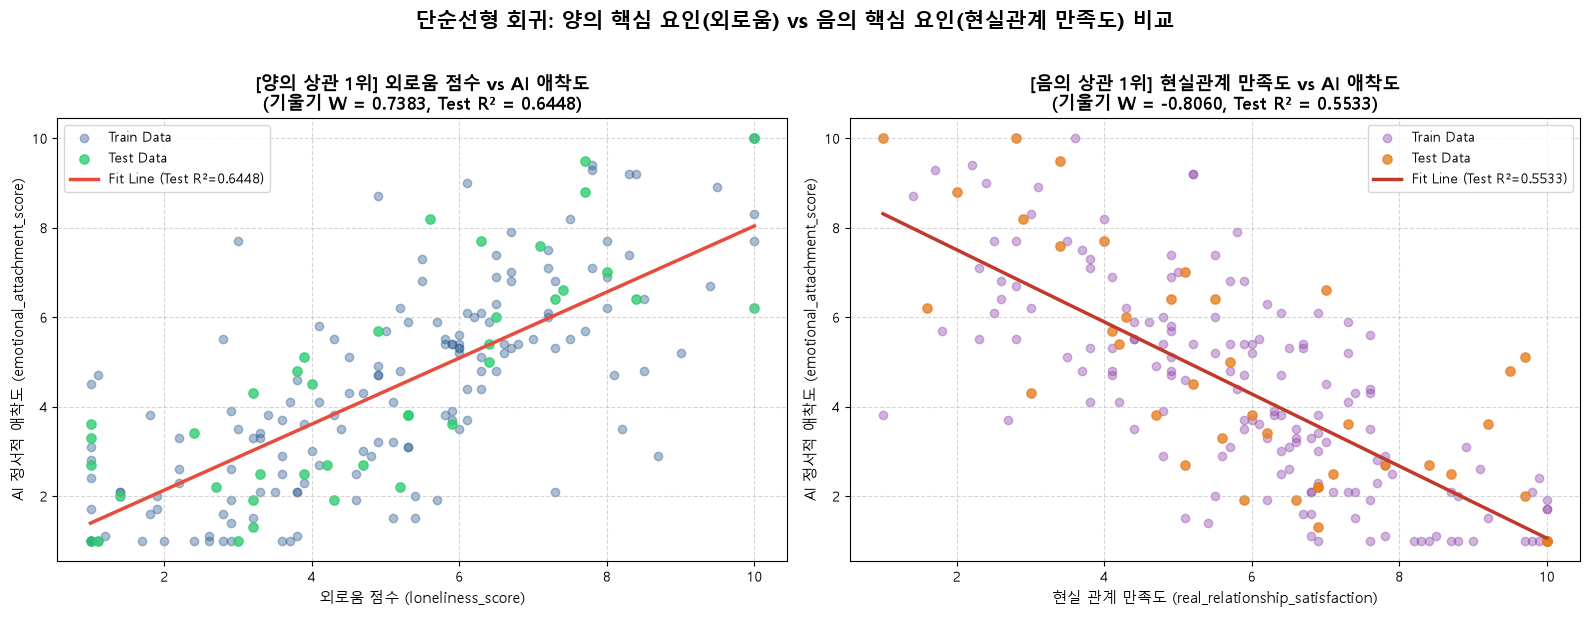

In [10]:
# ===========================================================================================================
# [심화 비교 분석] 음의 상관 1위(전체 2위) 'real_relationship_satisfaction' 단순선형 회귀 모델링
# ===========================================================================================================

# 1. 데이터 분할 (동일한 80:20 조건, random_state=42)
X_rel = df[['real_relationship_satisfaction']]
y_rel = df['emotional_attachment_score']

X_train_rel, X_test_rel, y_train_rel, y_test_rel = train_test_split(
    X_rel, y_rel, test_size=0.2, random_state=42
)

# 2. 모델 생성 및 학습
model_rel = LinearRegression()
model_rel.fit(X_train_rel, y_train_rel)

# 3. 회귀계수(W) 및 절편(b)
coef_rel = model_rel.coef_[0]
intercept_rel = model_rel.intercept_

# 4. 예측값 생성 및 평가 지표 계산
y_train_pred_rel = model_rel.predict(X_train_rel)
y_test_pred_rel = model_rel.predict(X_test_rel)

train_r2_rel = r2_score(y_train_rel, y_train_pred_rel)
test_r2_rel = r2_score(y_test_rel, y_test_pred_rel)
test_mse_rel = mean_squared_error(y_test_rel, y_test_pred_rel)
test_rmse_rel = np.sqrt(test_mse_rel)
test_mae_rel = mean_absolute_error(y_test_rel, y_test_pred_rel)

# ===========================================================================================================
# 5. 양의 상관(외로움) vs 음의 상관(현실만족도) 1:1 비교표
# ===========================================================================================================
compare_df = pd.DataFrame({
    '모델 구분': ['[양의 상관 1위] 외로움 점수 모델', '[음의 상관 1위] 현실관계 만족도 모델'],
    '독립변수 (X)': ['loneliness_score', 'real_relationship_satisfaction'],
    '상관계수 (r)': ['+0.760', '-0.747'],
    '학습된 회귀 방정식': [
        f'Y = {coef:.4f} * X + ({intercept:.4f})',
        f'Y = {coef_rel:.4f} * X + ({intercept_rel:.4f})'
    ],
    'Train R²': [f'{train_r2:.4f}', f'{train_r2_rel:.4f}'],
    'Test R²': [f'{test_r2:.4f}', f'{test_r2_rel:.4f}'],
    'Test RMSE': [f'{test_rmse:.4f}', f'{test_rmse_rel:.4f}'],
    'Test MAE': [f'{test_mae:.4f}', f'{test_mae_rel:.4f}']
})

print("=================== [단순선형 회귀: 핵심 2대 요인 1:1 성능 비교표] ===================")
display(compare_df)

# ===========================================================================================================
# 6. 두 모델의 회귀선 및 테스트 데이터 1:2 나란히 시각화 (Subplots)
# ===========================================================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (1) 좌측: 외로움 점수 모델 (우상향)
axes[0].scatter(X_train, y_train, color='#2b5c8f', alpha=0.4, label='Train Data')
axes[0].scatter(X_test, y_test, color='#2ecc71', alpha=0.8, s=45, label='Test Data')
X_line_lone = pd.DataFrame({'loneliness_score': np.linspace(X['loneliness_score'].min(), X['loneliness_score'].max(), 100)})
axes[0].plot(X_line_lone['loneliness_score'], model.predict(X_line_lone), color='#e74c3c', linewidth=2.5, label=f'Fit Line (Test R²={test_r2:.4f})')
axes[0].set_title(f'[양의 상관 1위] 외로움 점수 vs AI 애착도\n(기울기 W = {coef:.4f}, Test R² = {test_r2:.4f})', fontsize=13, fontweight='bold')
axes[0].set_xlabel('외로움 점수 (loneliness_score)', fontsize=11)
axes[0].set_ylabel('AI 정서적 애착도 (emotional_attachment_score)', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# (2) 우측: 현실 대인관계 만족도 모델 (우하향)
axes[1].scatter(X_train_rel, y_train_rel, color='#8e44ad', alpha=0.4, label='Train Data')
axes[1].scatter(X_test_rel, y_test_rel, color='#e67e22', alpha=0.8, s=45, label='Test Data')
X_line_rel = pd.DataFrame({'real_relationship_satisfaction': np.linspace(X_rel['real_relationship_satisfaction'].min(), X_rel['real_relationship_satisfaction'].max(), 100)})
axes[1].plot(X_line_rel['real_relationship_satisfaction'], model_rel.predict(X_line_rel), color='#c0392b', linewidth=2.5, label=f'Fit Line (Test R²={test_r2_rel:.4f})')
axes[1].set_title(f'[음의 상관 1위] 현실관계 만족도 vs AI 애착도\n(기울기 W = {coef_rel:.4f}, Test R² = {test_r2_rel:.4f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('현실 관계 만족도 (real_relationship_satisfaction)', fontsize=11)
axes[1].set_ylabel('AI 정서적 애착도 (emotional_attachment_score)', fontsize=11)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('단순선형 회귀: 양의 핵심 요인(외로움) vs 음의 핵심 요인(현실관계 만족도) 비교', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
